In [33]:
# Importing necessary libraries
# These libraries are essential for data manipulation, visualization, and machine learning
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.tree import export_text

In [34]:
#connecting to Google Drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [35]:
# Loading dataset into a pandas DataFrame
# The dataset contains customer information and their loan acceptance status
data = pd.read_csv("/content/drive/My Drive/PGP-AIML/Machine_Learning/Loan_Modelling/Loan_Modelling.csv")

In [36]:
# Problem Definition
# Defining the goal of the analysis
print("Objective: Predict liability customers' likelihood to purchase personal loans and identify key factors driving this decision.\n")

Objective: Predict liability customers' likelihood to purchase personal loans and identify key factors driving this decision.



In [37]:
# Data Overview
# Displaying the structure of the dataset to understand its size and column details
print("Data Overview:\n")
print(data.info())

Data Overview:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  5000 non-null   int64  
 1   Age                 5000 non-null   int64  
 2   Experience          5000 non-null   int64  
 3   Income              5000 non-null   int64  
 4   ZIPCode             5000 non-null   int64  
 5   Family              5000 non-null   int64  
 6   CCAvg               5000 non-null   float64
 7   Education           5000 non-null   int64  
 8   Mortgage            5000 non-null   int64  
 9   Personal_Loan       5000 non-null   int64  
 10  Securities_Account  5000 non-null   int64  
 11  CD_Account          5000 non-null   int64  
 12  Online              5000 non-null   int64  
 13  CreditCard          5000 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 547.0 KB
None


In [38]:
# Displaying basic statistical details for numerical columns to understand data distribution
print("\nSummary Statistics:\n")
print(data.describe())


Summary Statistics:

                ID          Age   Experience       Income       ZIPCode  \
count  5000.000000  5000.000000  5000.000000  5000.000000   5000.000000   
mean   2500.500000    45.338400    20.104600    73.774200  93169.257000   
std    1443.520003    11.463166    11.467954    46.033729   1759.455086   
min       1.000000    23.000000    -3.000000     8.000000  90005.000000   
25%    1250.750000    35.000000    10.000000    39.000000  91911.000000   
50%    2500.500000    45.000000    20.000000    64.000000  93437.000000   
75%    3750.250000    55.000000    30.000000    98.000000  94608.000000   
max    5000.000000    67.000000    43.000000   224.000000  96651.000000   

            Family        CCAvg    Education     Mortgage  Personal_Loan  \
count  5000.000000  5000.000000  5000.000000  5000.000000    5000.000000   
mean      2.396400     1.937938     1.881000    56.498800       0.096000   
std       1.147663     1.747659     0.839869   101.713802       0.294621  

In [39]:
# Fixing negative values in the Experience column
# Since experience cannot be negative, we will replace negative values with the absolute value
# Another approach could be replacing them with the median or mode, but here we assume they are entry errors

print("\nFixing Negative Experience Values\n")
print("Number of negative experience values before correction:", (data['Experience'] < 0).sum())
data['Experience'] = np.abs(data['Experience'])
print("Number of negative experience values after correction:", (data['Experience'] < 0).sum())
print("\nSummary Statistics for Experience (After Correction):\n", data['Experience'].describe())


Fixing Negative Experience Values

Number of negative experience values before correction: 52
Number of negative experience values after correction: 0

Summary Statistics for Experience (After Correction):
 count    5000.000000
mean       20.134600
std        11.415189
min         0.000000
25%        10.000000
50%        20.000000
75%        30.000000
max        43.000000
Name: Experience, dtype: float64


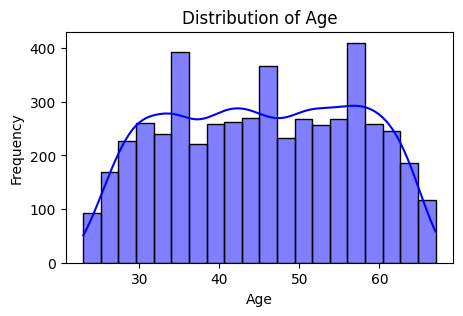

In [40]:
# Exploratory Data Analysis (EDA)
# Visualizing the distribution of customer ages to understand the demographic spread
plt.figure(figsize=(5, 3))
sns.histplot(data['Age'], bins=20, kde=True, color='blue')
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()


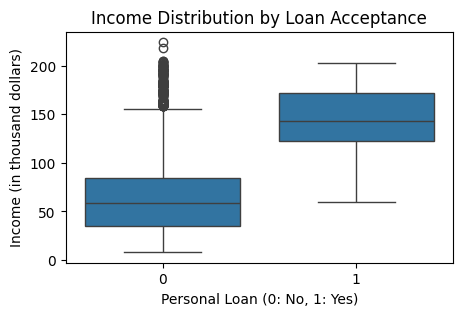

In [41]:
# Visualizing income distribution to observe differences between customers who accepted or rejected loans
plt.figure(figsize=(5, 3))
sns.boxplot(x='Personal_Loan', y='Income', data=data)
plt.title('Income Distribution by Loan Acceptance')
plt.xlabel('Personal Loan (0: No, 1: Yes)')
plt.ylabel('Income (in thousand dollars)')
plt.show()

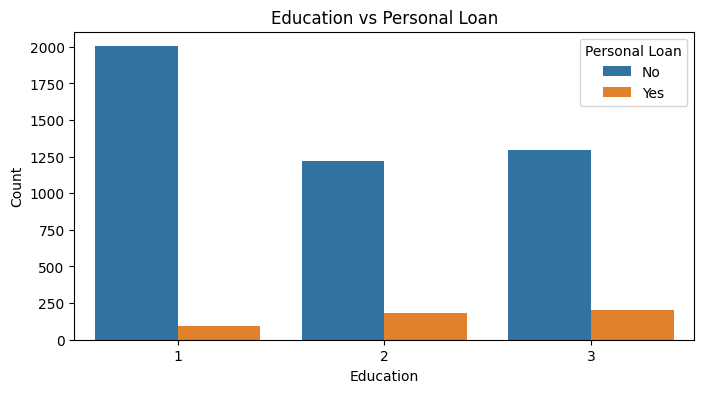

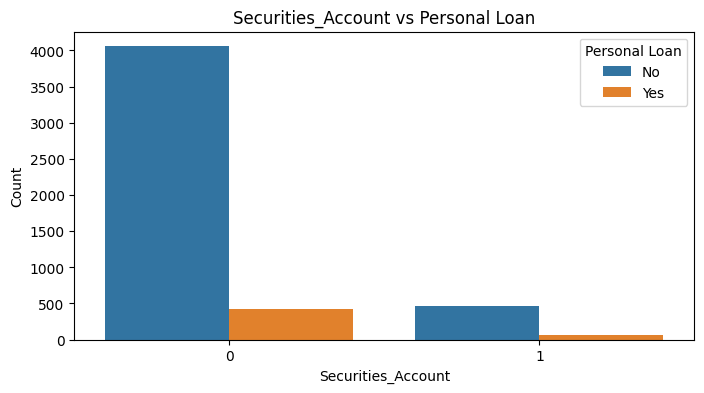

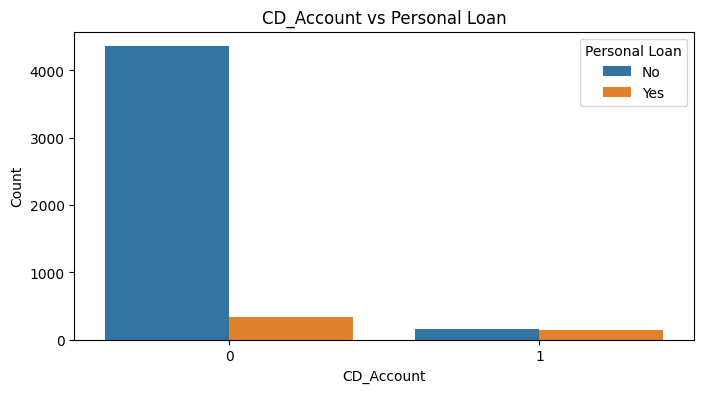

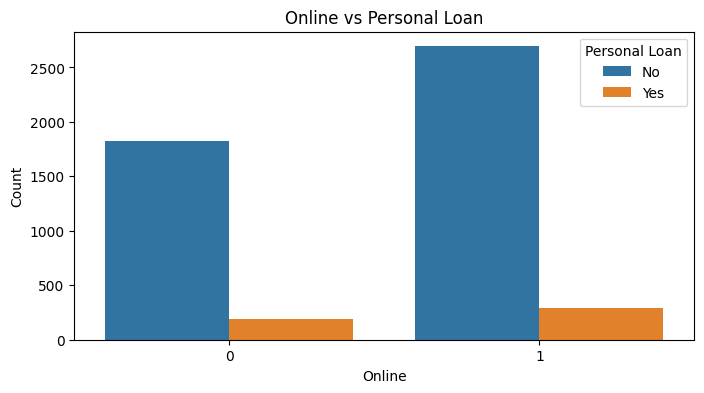

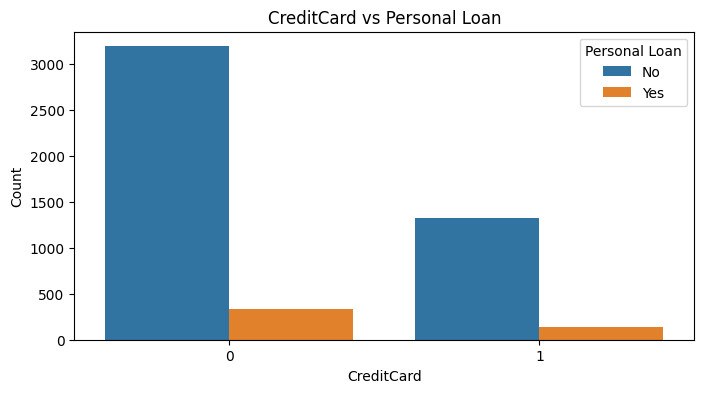

In [42]:
# Analyzing categorical features and their relationship with loan acceptance
# For each categorical column, visualize how its distribution relates to loan acceptance
categorical_cols = ['Education', 'Securities_Account', 'CD_Account', 'Online', 'CreditCard']
for col in categorical_cols:
    plt.figure(figsize=(8, 4))
    sns.countplot(x=col, hue='Personal_Loan', data=data)
    plt.title(f'{col} vs Personal Loan')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.legend(title='Personal Loan', labels=['No', 'Yes'])
    plt.show()

In [43]:
# Data Preprocessing
# Check for missing values to ensure data completeness

print("Missing Values:\n", data.isnull().sum())

Missing Values:
 ID                    0
Age                   0
Experience            0
Income                0
ZIPCode               0
Family                0
CCAvg                 0
Education             0
Mortgage              0
Personal_Loan         0
Securities_Account    0
CD_Account            0
Online                0
CreditCard            0
dtype: int64


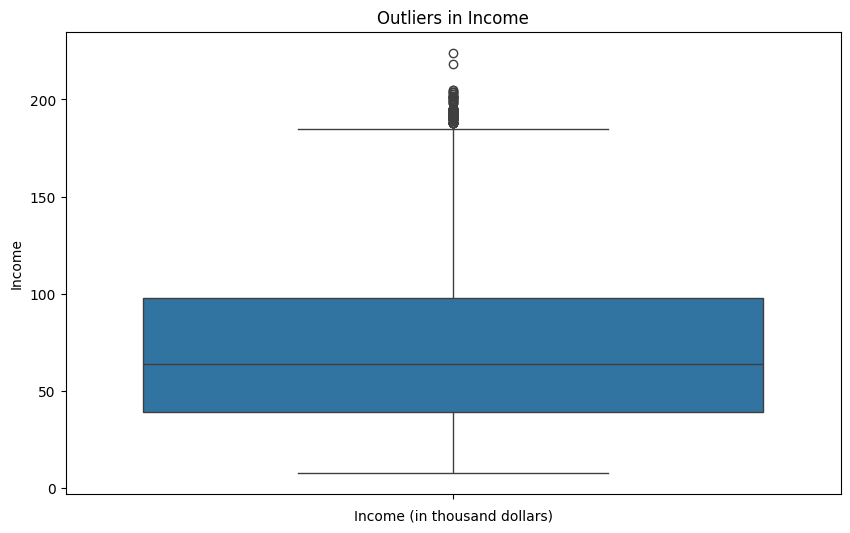

In [44]:
# Detecting outliers in the Income column using a box plot

plt.figure(figsize=(10, 6))
sns.boxplot(data['Income'])
plt.title('Outliers in Income')
plt.xlabel('Income (in thousand dollars)')
plt.show()

In [45]:
# Removing outliers in the Income column using the IQR method
# Outliers are data points significantly different from the rest, which can distort the model

Q1 = data['Income'].quantile(0.25)  # Calculate the 25th percentile (Q1)
Q3 = data['Income'].quantile(0.75)  # Calculate the 75th percentile (Q3)
IQR = Q3 - Q1  # Interquartile Range (IQR)
outlier_condition = (data['Income'] < (Q1 - 1.5 * IQR)) | (data['Income'] > (Q3 + 1.5 * IQR))
data = data[~outlier_condition]  # Retain only rows without outliers

In [46]:
# Feature Selection and Encoding
# Droppping unnecessary columns (ID and ZIPCode) and separate features (X) and target variable (y)
X = data.drop(['ID', 'ZIPCode', 'Personal_Loan'], axis=1)
y = data['Personal_Loan']

In [47]:
# Splitting the dataset into training and testing sets
# Splitting the dataset into training and testing sets
# Train-test split helps evaluate model performance on unseen data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=18)

In [48]:
# Model Building - Decision Tree
# Initializing and training a decision tree classifier to predict loan acceptance
clf = DecisionTreeClassifier(random_state=18)
clf.fit(X_train, y_train)

DecisionTreeClassifier(random_state=18)

In [49]:
# Evaluating the initial decision tree model on the test data
y_pred = clf.predict(X_test)
print("\nModel Performance:\n")
# Calculating and display accuracy of predictions
print("Accuracy:", accuracy_score(y_test, y_pred))
# Displaying the confusion matrix to understand correct and incorrect predictions
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
# Displaying detailed classification metrics (precision, recall, F1-score)
print("Classification Report:\n", classification_report(y_test, y_pred))


Model Performance:

Accuracy: 0.9836956521739131
Confusion Matrix:
 [[1342    9]
 [  15  106]]
Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99      1351
           1       0.92      0.88      0.90       121

    accuracy                           0.98      1472
   macro avg       0.96      0.93      0.94      1472
weighted avg       0.98      0.98      0.98      1472



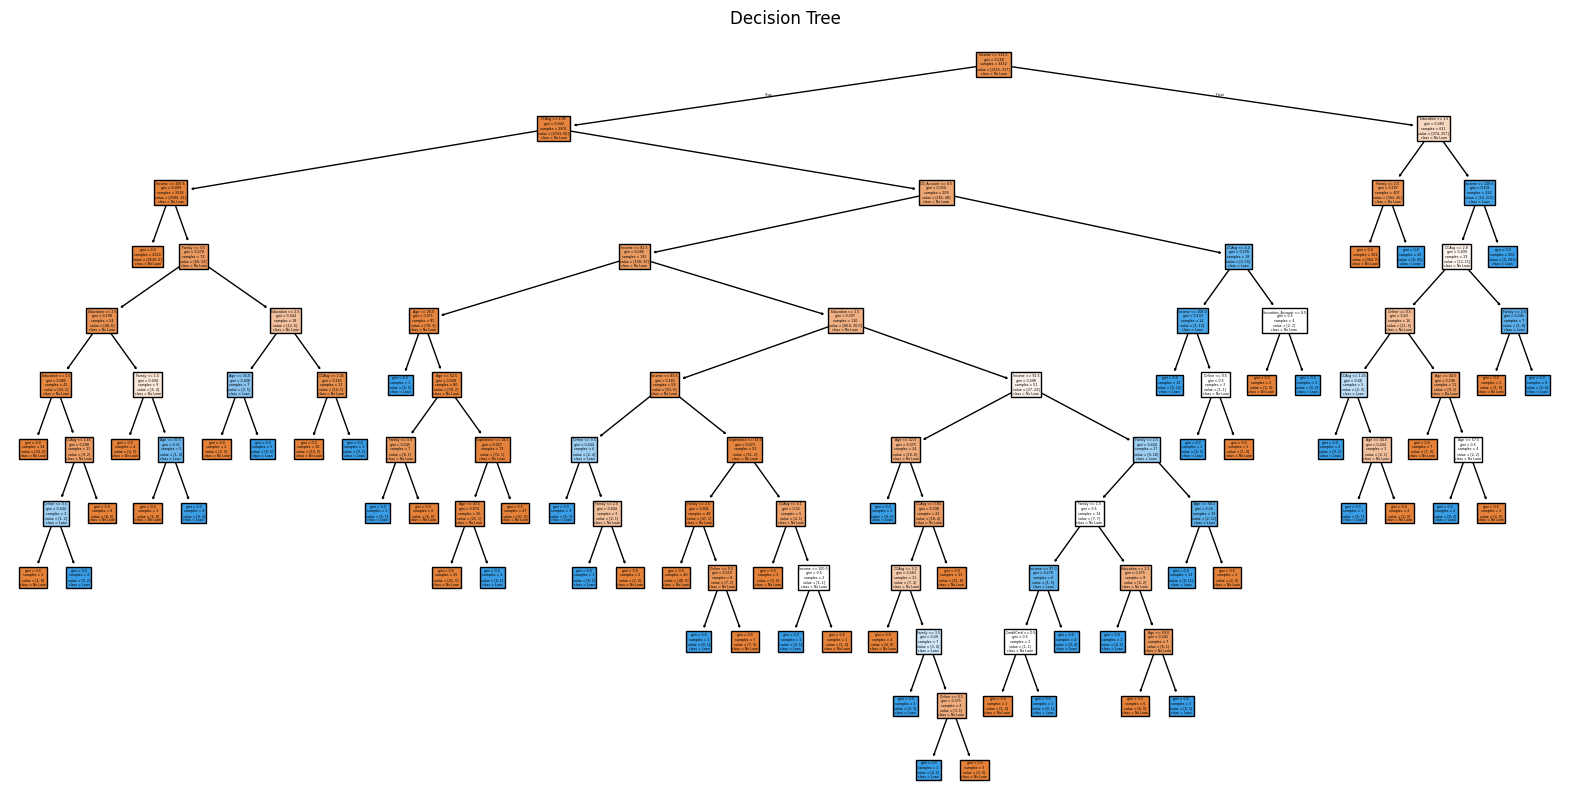

In [50]:
# Visualizing the trained decision tree
plt.figure(figsize=(20, 10))
plot_tree(clf, feature_names=X.columns, class_names=['No Loan', 'Loan'], filled=True)
plt.title('Decision Tree')
plt.show()

In [51]:
# Improve Model - Pre-pruning
# Applying pre-pruning by limiting tree depth to prevent overfitting
clf_pruned = DecisionTreeClassifier(max_depth=3, random_state=18)
clf_pruned.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3, random_state=18)

In [52]:
# Evaluating the pruned decision tree model
y_pruned_pred = clf_pruned.predict(X_test)
print("\nPruned Model Performance:\n")
# Calculating and displaying accuracy for the pruned model
print("Accuracy:", accuracy_score(y_test, y_pruned_pred))
# Displaying confusion matrix for pruned model to analyze predictions
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pruned_pred))
# Displaying detailed classification metrics for pruned model
print("Classification Report:\n", classification_report(y_test, y_pruned_pred))


Pruned Model Performance:

Accuracy: 0.9836956521739131
Confusion Matrix:
 [[1348    3]
 [  21  100]]
Classification Report:
               precision    recall  f1-score   support

           0       0.98      1.00      0.99      1351
           1       0.97      0.83      0.89       121

    accuracy                           0.98      1472
   macro avg       0.98      0.91      0.94      1472
weighted avg       0.98      0.98      0.98      1472



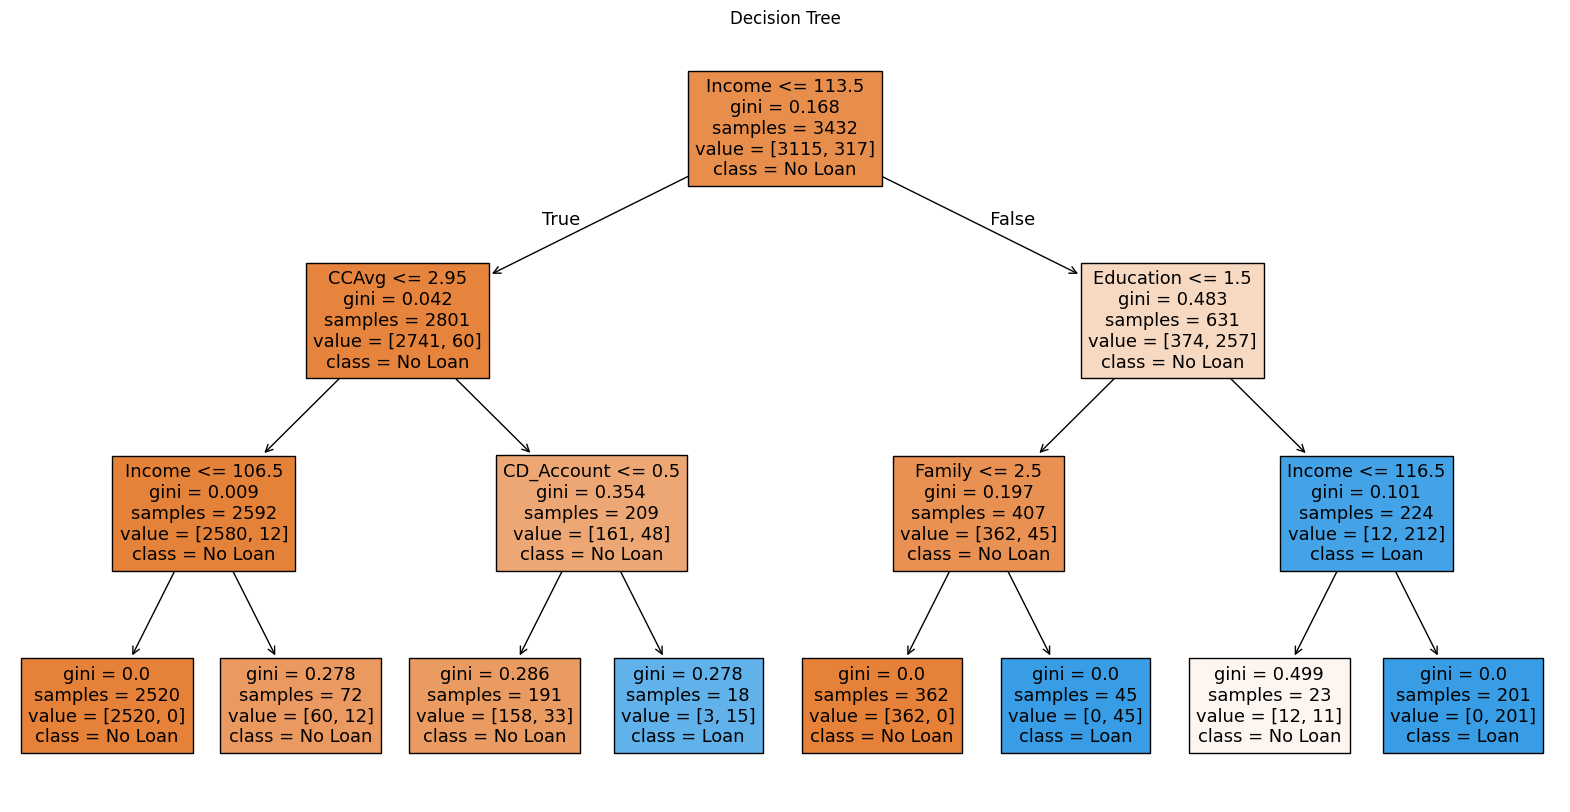

In [53]:
# Visualizing the pruned decision tree
plt.figure(figsize=(20, 10))
plot_tree(clf_pruned, feature_names=X.columns, class_names=['No Loan', 'Loan'], filled=True)
plt.title('Decision Tree')
plt.show()

In [54]:
# Extracting and display decision rules from the pruned decision tree
rules = export_text(clf_pruned, feature_names=list(X.columns))
print("\nDecision Rules:\n", rules)


Decision Rules:
 |--- Income <= 113.50
|   |--- CCAvg <= 2.95
|   |   |--- Income <= 106.50
|   |   |   |--- class: 0
|   |   |--- Income >  106.50
|   |   |   |--- class: 0
|   |--- CCAvg >  2.95
|   |   |--- CD_Account <= 0.50
|   |   |   |--- class: 0
|   |   |--- CD_Account >  0.50
|   |   |   |--- class: 1
|--- Income >  113.50
|   |--- Education <= 1.50
|   |   |--- Family <= 2.50
|   |   |   |--- class: 0
|   |   |--- Family >  2.50
|   |   |   |--- class: 1
|   |--- Education >  1.50
|   |   |--- Income <= 116.50
|   |   |   |--- class: 0
|   |   |--- Income >  116.50
|   |   |   |--- class: 1



In [57]:
# Recommendations based on analysis
# Providing actionable insights based on the model's findings
print("\nRecommendations:\n")
print("1. Focus marketing campaigns on customers with high income, advanced education levels, and regular credit card usage.")
print("2. Target customers using online banking, as they are more likely to convert.")
print("3. Segment the customer base based on decision tree insights for personalized marketing.")


Recommendations:

1. Focus marketing campaigns on customers with high income, advanced education levels, and regular credit card usage.
2. Target customers using online banking, as they are more likely to convert.
3. Segment the customer base based on decision tree insights for personalized marketing.
